# Business Understanding

Le diabète est l'une des maladies chroniques les plus répandues dans le monde. Une détection précoce et une compréhension des facteurs de risque sont essentielles pour :

- **Prévenir** l'apparition du diabète de type 2 chez les personnes à risque,
- **Optimiser** les programmes de dépistage en ciblant les profils à risque élevé,
- **Personnaliser** les recommandations médicales selon les caractéristiques du patient,
- **Réduire** les coûts de santé grâce à une intervention précoce,
- **Soutenir** les décisions cliniques et de santé publique basées sur les données.

# Le Domaine

Santé – Médecine préventive, dépistage du diabète et analyse du risque patient

---

# DSO1 : Segmentation des patients
**BO1** : Identifier des groupes de patients selon leur profil de risque (lifestyle, biométrique, antécédents) pour des campagnes de prévention ciblées.

# DSO2 : Régression – Prédire le `diabetes_risk_score`
**BO2** : Minimiser les erreurs de prédiction du score de risque pour éviter de sous-estimer la dangerosité d'un profil patient.

# DSO3 : Classification binaire – Prédire `diagnosed_diabetes` (0 / 1)
**BO3** : Identifier les patients diabétiques à partir de leurs caractéristiques cliniques et comportementales.

# DSO4 : Classification multiclasse – Prédire `diabetes_stage`
**BO4** : Classifier le stade du diabète (No Diabetes, Pre-Diabetes, Type 1, Type 2, Gestational) pour orienter la prise en charge médicale.

# DATA UNDERSTANDING – diabetes_dataset

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_squared_error, r2_score,
                             silhouette_score)

%matplotlib inline
print("Importations de base terminées!")

Importations de base terminées!


In [3]:
df = pd.read_csv("./data/diabetes_dataset.csv")
df_raw = df.copy()
print("Dataset chargé avec succès!")

Dataset chargé avec succès!


In [4]:
print(df.shape)

(100000, 31)


In [5]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

Ce dataset contient **100 000 observations** et **31 variables** liées aux caractéristiques médicales, comportementales et démographiques des patients. Chaque ligne représente un patient.

### 🏷️ Description des variables

**Démographiques :**
- `age` : âge du patient
- `gender` : sexe (Male / Female)
- `ethnicity` : origine ethnique
- `education_level` : niveau d'éducation
- `income_level` : niveau de revenu
- `employment_status` : statut professionnel

**Mode de vie :**
- `smoking_status` : statut tabagique
- `alcohol_consumption_per_week` : consommation d'alcool par semaine
- `physical_activity_minutes_per_week` : activité physique (minutes/semaine)
- `diet_score` : score de qualité alimentaire
- `sleep_hours_per_day` : heures de sommeil par jour
- `screen_time_hours_per_day` : temps d'écran par jour

**Antécédents médicaux :**
- `family_history_diabetes` : antécédents familiaux de diabète (0/1)
- `hypertension_history` : antécédents d'hypertension (0/1)
- `cardiovascular_history` : antécédents cardiovasculaires (0/1)

**Biométriques & cliniques :**
- `bmi` : indice de masse corporelle
- `waist_to_hip_ratio` : ratio taille/hanches
- `systolic_bp` / `diastolic_bp` : tension artérielle
- `heart_rate` : fréquence cardiaque
- `cholesterol_total`, `hdl_cholesterol`, `ldl_cholesterol`, `triglycerides` : bilan lipidique
- `glucose_fasting`, `glucose_postprandial` : glycémie à jeun et post-prandiale
- `insulin_level` : niveau d'insuline
- `hba1c` : hémoglobine glyquée
- `diabetes_risk_score` : score de risque diabète

**Variables cibles :**
- `diabetes_stage` : stade du diabète (No Diabetes, Pre-Diabetes, Type 1, Type 2, Gestational)
- `diagnosed_diabetes` : variable binaire (0 = non diabétique, 1 = diabétique)

In [7]:
# Vérifier les valeurs manquantes
print(df.isnull().sum())

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


✅ Aucune valeur manquante détectée. Le dataset est propre sur ce point.

In [8]:
# Statistiques descriptives
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


# Visualisations exploratoires

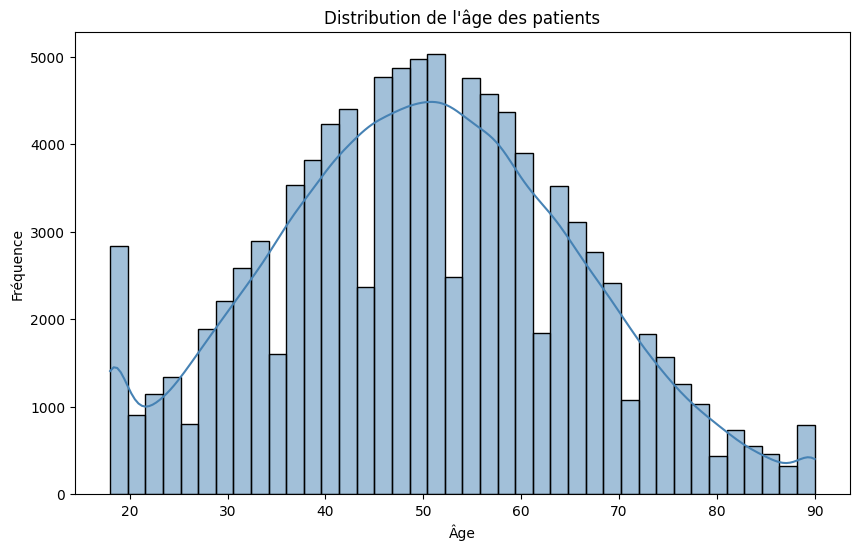

In [9]:
# Distribution de l'âge
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=40, kde=True, color='steelblue')
plt.title('Distribution de l\'âge des patients')
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.show()

La distribution de l'âge montre une répartition relativement uniforme entre 20 et 80 ans, ce qui est représentatif d'une population adulte diversifiée.

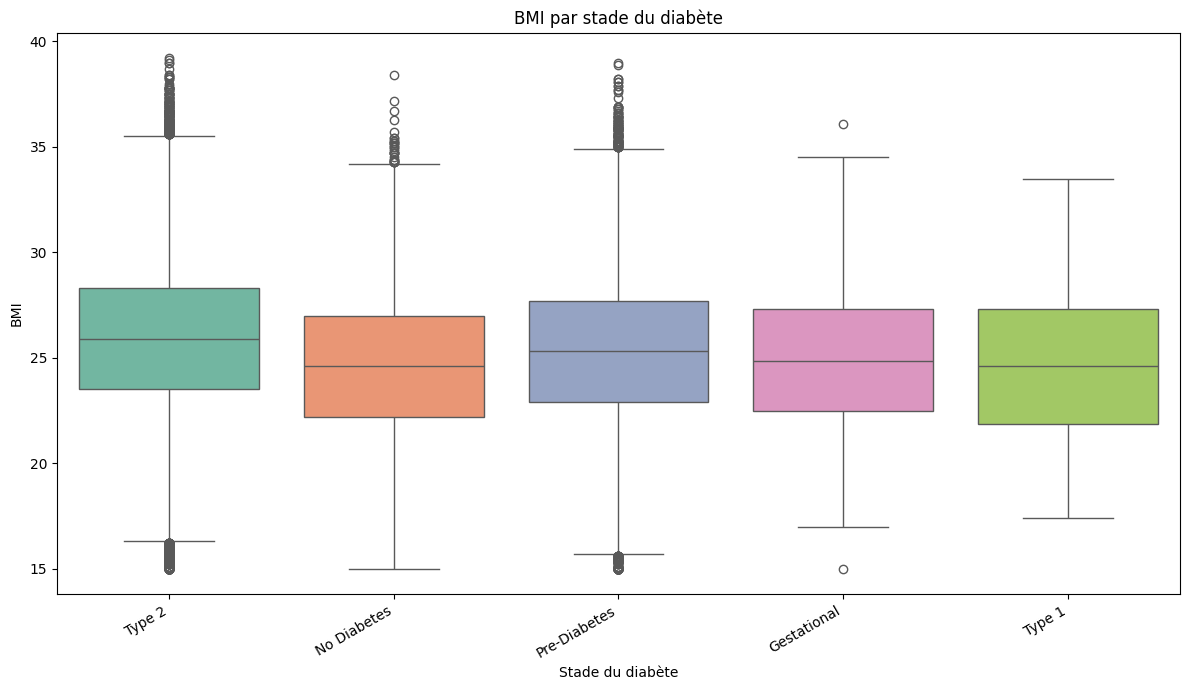

In [10]:
# Distribution du BMI par stade du diabète
plt.figure(figsize=(12, 7))
sns.boxplot(x='diabetes_stage', y='bmi', data=df, palette='Set2')
plt.title('BMI par stade du diabète')
plt.xlabel('Stade du diabète')
plt.ylabel('BMI')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Les patients atteints de Type 2 présentent les BMI les plus élevés, confirmant le lien bien établi entre obésité et diabète de type 2.

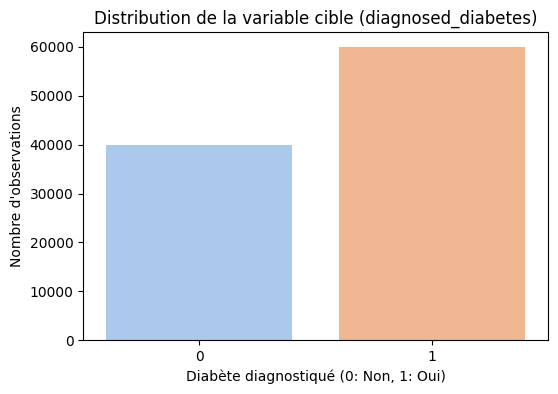

In [11]:
# Distribution de la variable cible binaire
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosed_diabetes', data=df, palette='pastel')
plt.title('Distribution de la variable cible (diagnosed_diabetes)')
plt.xlabel('Diabète diagnostiqué (0: Non, 1: Oui)')
plt.ylabel('Nombre d\'observations')
plt.show()

La variable cible est légèrement déséquilibrée avec ~60% de cas positifs. Ce déséquilibre devra être pris en compte lors de la modélisation.

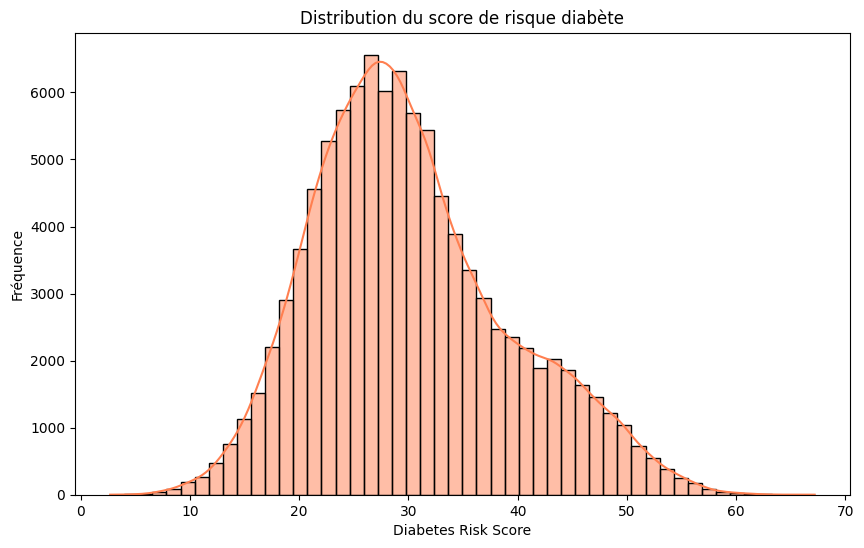

In [12]:
# Distribution du diabetes_risk_score
plt.figure(figsize=(10, 6))
sns.histplot(df['diabetes_risk_score'], bins=50, kde=True, color='coral')
plt.title('Distribution du score de risque diabète')
plt.xlabel('Diabetes Risk Score')
plt.ylabel('Fréquence')
plt.show()

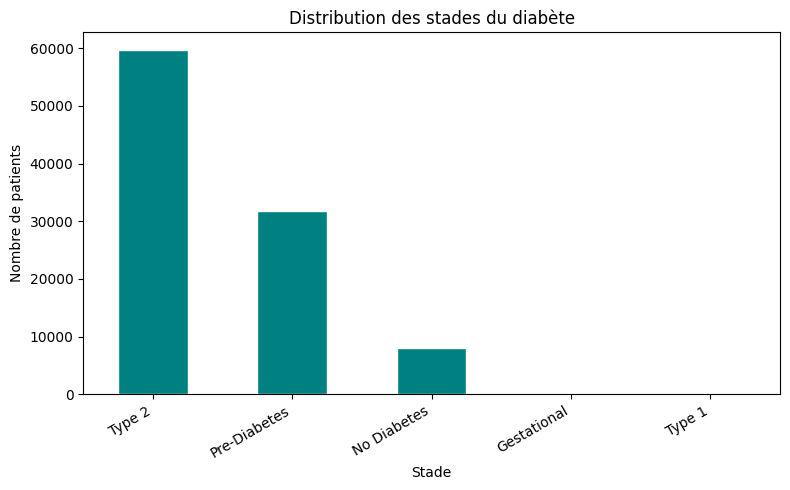

In [13]:
# Stades du diabète
plt.figure(figsize=(8, 5))
df['diabetes_stage'].value_counts().plot(kind='bar', color='teal', edgecolor='white')
plt.title('Distribution des stades du diabète')
plt.xlabel('Stade')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

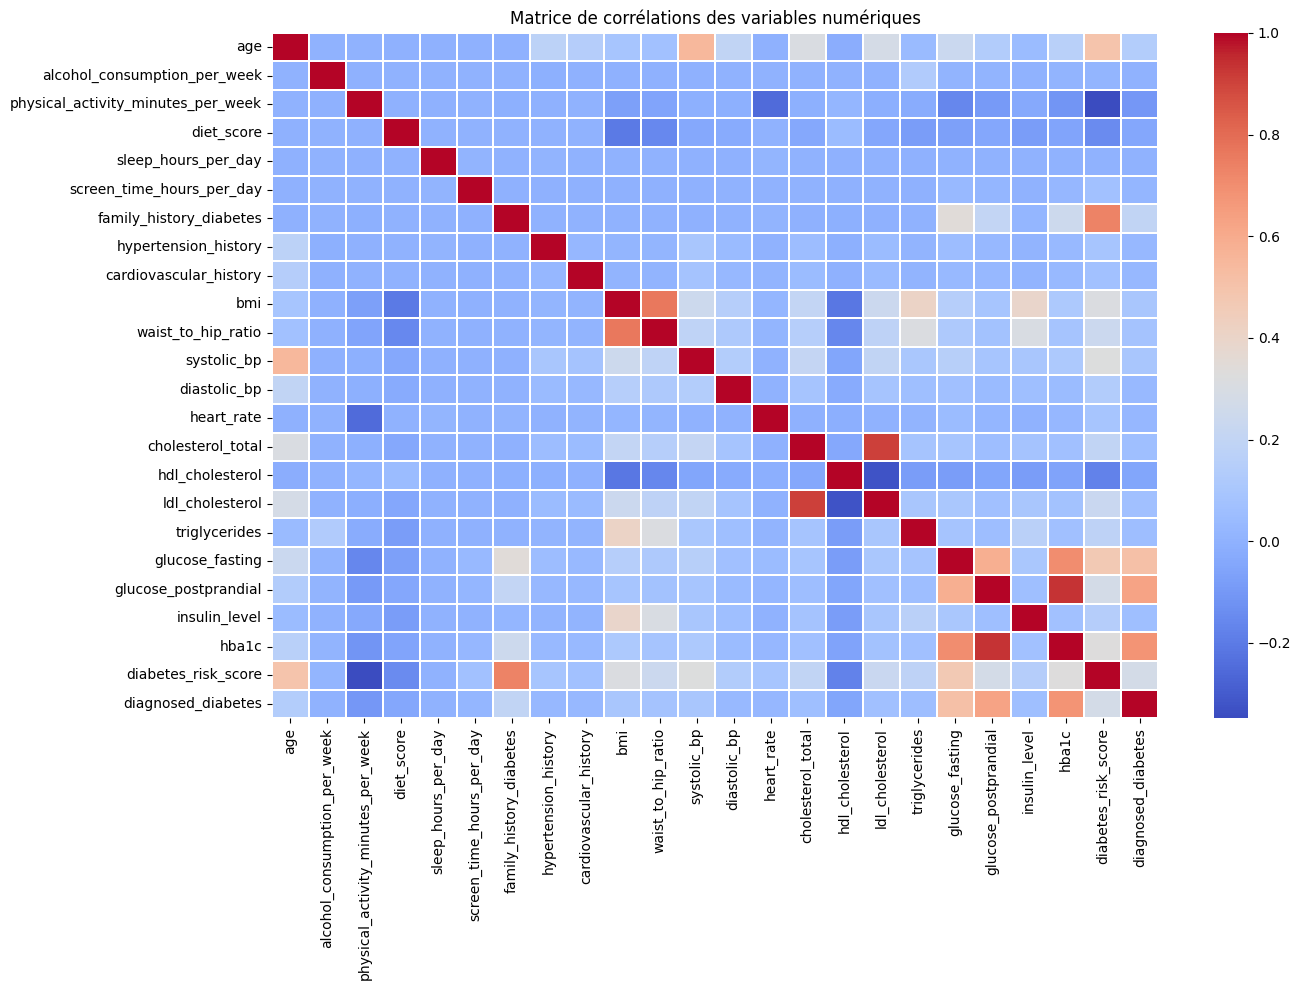

In [14]:
# Matrice de corrélation
plt.figure(figsize=(14, 10))
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm', linewidths=0.3)
plt.title("Matrice de corrélations des variables numériques")
plt.tight_layout()
plt.show()

# Interprétation de la matrice de corrélation

- `glucose_fasting`, `glucose_postprandial`, `hba1c` et `insulin_level` sont fortement corrélées entre elles → indicateurs directs du métabolisme glucidique.
- `bmi` et `waist_to_hip_ratio` sont positivement corrélés → mesures complémentaires de l'adiposité.
- `diabetes_risk_score` est fortement corrélé à `diagnosed_diabetes` → le score synthétise bien le risque réel.
- `hdl_cholesterol` est négativement corrélé à `bmi` → le bon cholestérol diminue avec l'obésité.
- Les variables de mode de vie (`diet_score`, `physical_activity_minutes_per_week`) ont des corrélations plus faibles mais non nulles avec les variables cibles.

# DATA PREPARATION

In [15]:
# Copie de travail
df_prep = df.copy()

# Encodage LabelEncoder pour les variables catégorielles ordinales
le = LabelEncoder()
cat_cols = ['gender', 'ethnicity', 'education_level', 'income_level',
            'employment_status', 'smoking_status', 'diabetes_stage']

for col in cat_cols:
    df_prep[col] = le.fit_transform(df_prep[col])

print("✅ Encodage terminé")
df_prep.head()

✅ Encodage terminé


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,1,0,1,2,0,2,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,4,1
1,48,0,4,1,3,0,1,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,1,0
2,60,1,2,1,3,3,2,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,4,1
3,74,0,1,1,1,1,2,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,4,1
4,46,1,4,0,3,1,2,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,4,1


In [16]:
# Vérification des types après encodage
print(df_prep.dtypes)

age                                     int64
gender                                  int64
ethnicity                               int64
education_level                         int64
income_level                            int64
employment_status                       int64
smoking_status                          int64
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                   

In [17]:
# Standardisation des variables numériques
num_features = ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week',
                'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day',
                'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp',
                'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
                'triglycerides', 'glucose_fasting', 'glucose_postprandial',
                'insulin_level', 'hba1c', 'diabetes_risk_score']

scaler_prep = StandardScaler()
df_prep[num_features] = scaler_prep.fit_transform(df_prep[num_features])

print("✅ Standardisation terminée")
df_prep.describe().round(3)

✅ Standardisation terminée


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
count,100000.000,100000.000,100000.000,100000.0,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,...,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.00
mean,0.000,0.518,2.533,1.0,2.500,0.698,1.396,-0.000,-0.000,0.000,...,0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,3.111,0.60
std,1.000,0.538,1.490,1.0,1.115,1.024,0.802,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.117,0.49
min,-2.058,0.000,0.000,0.0,0.000,0.000,0.000,-1.413,-1.409,-3.366,...,-3.316,-1.587,-2.109,-3.760,-2.910,-1.425,-3.097,-3.037,0.000,0.00
25%,-0.713,0.000,1.000,0.0,2.000,0.000,1.000,-0.708,-0.733,-0.671,...,-0.686,-0.749,-0.702,-0.671,-0.680,-0.802,-0.677,-0.709,2.000,0.00
50%,-0.008,0.000,3.000,1.0,3.000,0.000,2.000,-0.003,-0.224,0.003,...,-0.004,-0.030,-0.011,-0.009,-0.001,-0.055,-0.001,-0.135,4.000,1.00
75%,0.697,1.000,4.000,1.0,3.000,1.000,2.000,0.703,0.487,0.677,...,0.678,0.689,0.681,0.653,0.678,0.684,0.675,0.593,4.000,1.00
max,2.556,2.000,4.000,3.0,4.000,3.000,2.000,5.640,8.460,2.249,...,4.281,4.792,5.131,4.478,4.104,4.675,4.029,4.081,4.000,1.00


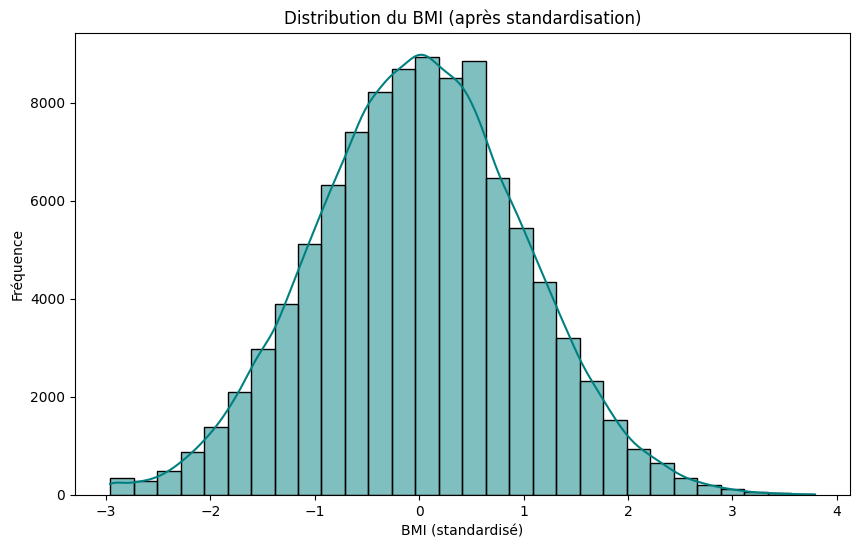

In [18]:
# Visualisation post-préparation : distribution du BMI
plt.figure(figsize=(10, 6))
sns.histplot(df_prep['bmi'], bins=30, kde=True, color='teal')
plt.title('Distribution du BMI (après standardisation)')
plt.xlabel('BMI (standardisé)')
plt.ylabel('Fréquence')
plt.show()

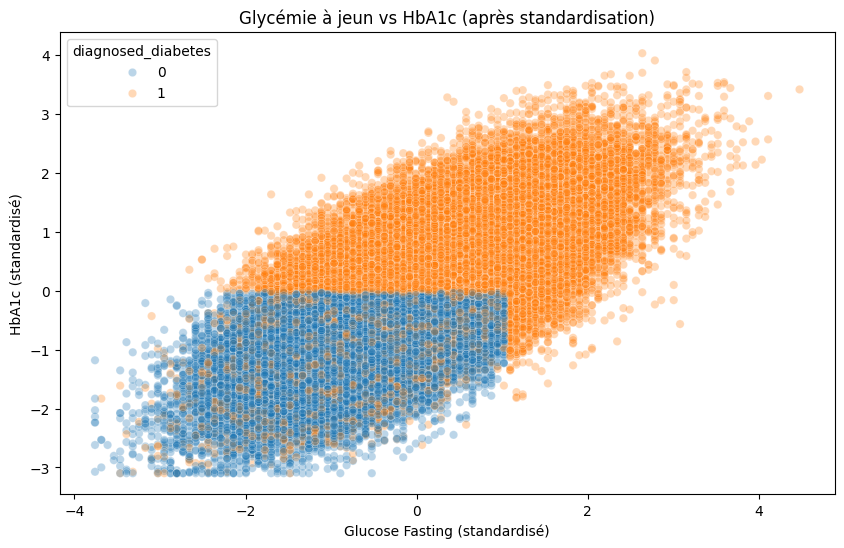

In [19]:
# Nuage de points : glucose_fasting vs hba1c
plt.figure(figsize=(10, 6))
sns.scatterplot(x='glucose_fasting', y='hba1c', hue='diagnosed_diabetes', data=df_prep, alpha=0.3)
plt.title('Glycémie à jeun vs HbA1c (après standardisation)')
plt.xlabel('Glucose Fasting (standardisé)')
plt.ylabel('HbA1c (standardisé)')
plt.show()

# ACP (Analyse en Composantes Principales)

## DSO1 : Segmentation des patients
## BO1 : Améliorer la prévention ciblée

### Variables utilisées dans l'ACP

| Variable | Justification |
|---|---|
| age | facteur de risque majeur |
| bmi | indicateur d'obésité |
| waist_to_hip_ratio | adiposité abdominale |
| glucose_fasting | glycémie à jeun |
| glucose_postprandial | réponse glycémique |
| hba1c | glycémie long terme |
| insulin_level | résistance à l'insuline |
| cholesterol_total | facteur cardiovasculaire |
| triglycerides | dyslipidémie |
| diabetes_risk_score | score de risque global |

In [20]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Variables quantitatives pour l'ACP
quantitative_vars = [
    'age', 'bmi', 'waist_to_hip_ratio', 'glucose_fasting',
    'glucose_postprandial', 'hba1c', 'insulin_level',
    'cholesterol_total', 'triglycerides', 'diabetes_risk_score'
]

X_pca_data = df_prep[quantitative_vars]

# Imputation puis normalisation
imputer = SimpleImputer(strategy='mean')
X_imp = imputer.fit_transform(X_pca_data)

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_imp)

# ACP à 2 composantes
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df_prep['PC1'] = components[:, 0]
df_prep['PC2'] = components[:, 1]

print("Variance expliquée par composante :", pca.explained_variance_ratio_)
print("Variance cumulée :", pca.explained_variance_ratio_.sum())

Variance expliquée par composante : [0.31738592 0.20507867]
Variance cumulée : 0.5224645938648453


In [21]:
# Contributions des variables aux PC
loadings_df = pd.DataFrame(pca.components_.T,
                           columns=['PC1', 'PC2'],
                           index=quantitative_vars)
print(loadings_df)

print("\nTop 3 variables pour PC1:")
print(loadings_df['PC1'].abs().sort_values(ascending=False).head(3))
print("\nTop 3 variables pour PC2:")
print(loadings_df['PC2'].abs().sort_values(ascending=False).head(3))

                           PC1       PC2
age                   0.241331 -0.022716
bmi                   0.319676  0.478121
waist_to_hip_ratio    0.282966  0.456875
glucose_fasting       0.413856 -0.275693
glucose_postprandial  0.395838 -0.374982
hba1c                 0.424100 -0.379217
insulin_level         0.193014  0.294925
cholesterol_total     0.173035  0.133055
triglycerides         0.196969  0.311185
diabetes_risk_score   0.381680  0.014336

Top 3 variables pour PC1:
hba1c                   0.424100
glucose_fasting         0.413856
glucose_postprandial    0.395838
Name: PC1, dtype: float64

Top 3 variables pour PC2:
bmi                   0.478121
waist_to_hip_ratio    0.456875
hba1c                 0.379217
Name: PC2, dtype: float64


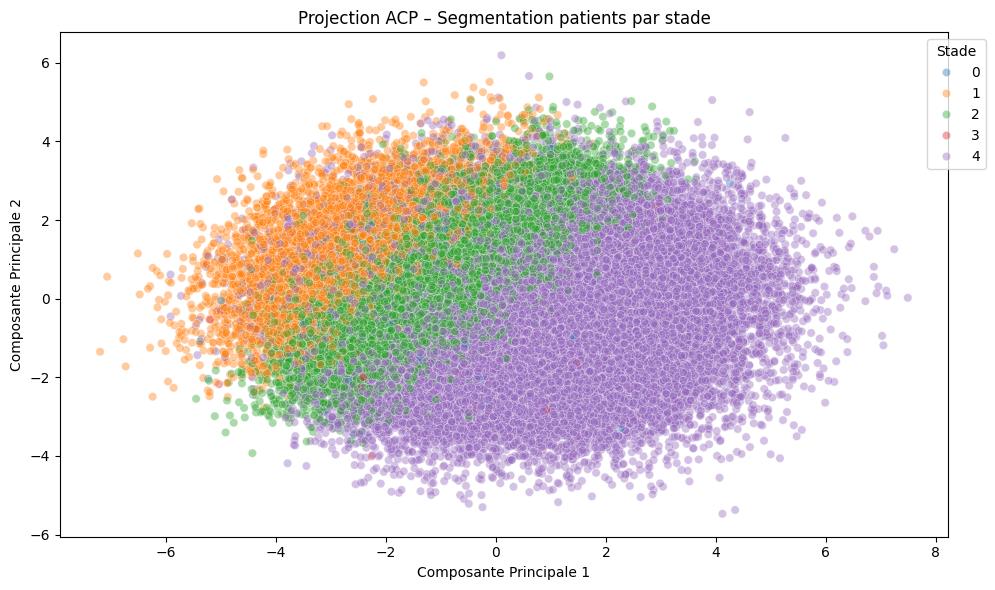

In [22]:
# Visualisation ACP par stade du diabète
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_prep, hue='diabetes_stage', palette='tab10', alpha=0.4)
plt.title("Projection ACP – Segmentation patients par stade")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.legend(title='Stade', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

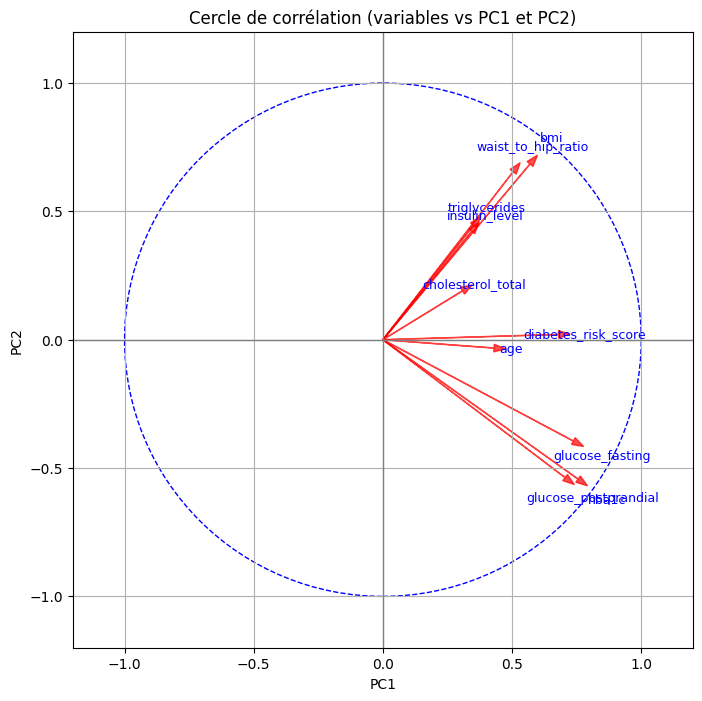

In [23]:
# Cercle de corrélation
loadings_circle = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(8, 8))
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--')
plt.gca().add_artist(circle)

for i, var in enumerate(quantitative_vars):
    plt.arrow(0, 0, loadings_circle[i, 0], loadings_circle[i, 1],
              color='r', alpha=0.7, head_width=0.03)
    plt.text(loadings_circle[i, 0]*1.15, loadings_circle[i, 1]*1.15,
             var, color='b', ha='center', va='center', fontsize=9)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cercle de corrélation (variables vs PC1 et PC2)")
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.grid()
plt.show()

**PC1** → axe "risque métabolique" (glucose, hba1c, insulin_level, diabetes_risk_score)

**PC2** → axe "profil lipidique et biométrique" (cholesterol, triglycerides, bmi, waist_to_hip_ratio)

# K-Means

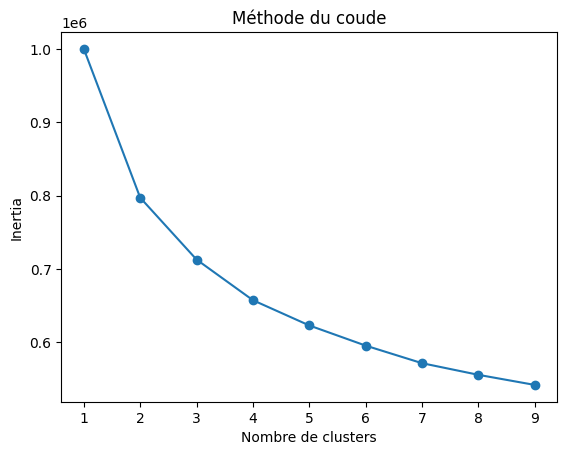

In [24]:
from sklearn.cluster import KMeans, DBSCAN

# Méthode du coude
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("Méthode du coude")
plt.show()

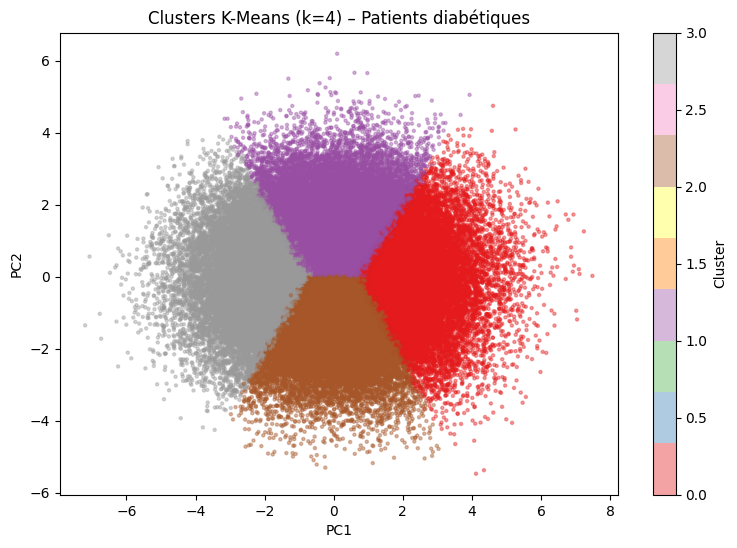

In [25]:
# K = 4 semble optimal (coude visible)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

# Visualisation avec PCA
pca_km = PCA(n_components=2)
X_pca_km = pca_km.fit_transform(X_scaled)
plt.figure(figsize=(9, 6))
plt.scatter(X_pca_km[:, 0], X_pca_km[:, 1], c=clusters_kmeans, cmap='Set1', alpha=0.4, s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters K-Means (k=4) – Patients diabétiques")
plt.colorbar(label='Cluster')
plt.show()

# DBSCAN

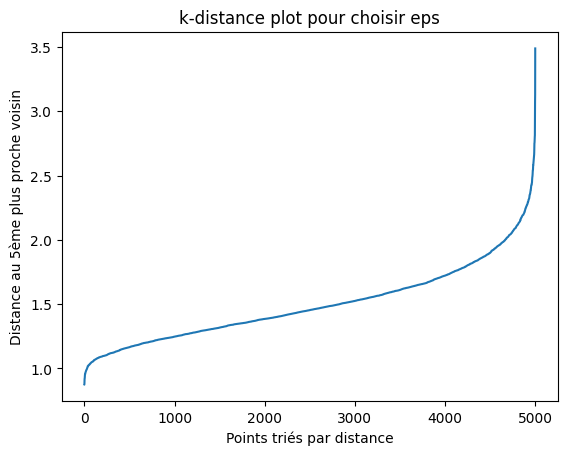

In [26]:
from sklearn.neighbors import NearestNeighbors

# Utilisation d'un échantillon pour la performance
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample = X_scaled[sample_idx]

k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_sample)
distances, _ = neighbors.kneighbors(X_sample)

distances_sorted = np.sort(distances[:, k-1])
plt.plot(distances_sorted)
plt.ylabel(f"Distance au {k}ème plus proche voisin")
plt.xlabel("Points triés par distance")
plt.title("k-distance plot pour choisir eps")
plt.show()

In [27]:
# Appliquer DBSCAN sur l'échantillon
dbscan = DBSCAN(eps=1.5, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_sample)
df_prep['cluster_dbscan'] = -1
df_prep.loc[sample_idx, 'cluster_dbscan'] = clusters_dbscan

print(df_prep['cluster_dbscan'].value_counts())

cluster_dbscan
-1    96158
 0     3830
 3        5
 1        4
 2        3
Name: count, dtype: int64


**Interprétation DBSCAN :**

- **Cluster 0** : groupe principal des patients au profil standard.
- **Cluster -1** : outliers – patients avec des caractéristiques très atypiques (possibles erreurs de mesure ou cas extrêmes).
- **Clusters 1+** : micro-segments spécialisés (ex: profil très jeune, ou très élevé en glucose).

**Conclusion :** K-Means donne 4 segments exploitables pour des actions de prévention ciblées. DBSCAN isole les cas atypiques qui méritent une attention médicale particulière.

# DSO2 : Régression – Prédire `diabetes_risk_score`
**BO2** : Réduire les erreurs de prédiction du score de risque pour optimiser les décisions cliniques.

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Cible et features
y_reg = df['diabetes_risk_score'].copy()
X_reg = df.drop(columns=['diabetes_risk_score', 'diagnosed_diabetes', 'diabetes_stage'])

# Colonnes numériques et catégorielles
num_cols_reg = X_reg.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_reg = X_reg.select_dtypes(include=['object']).columns.tolist()

# Préprocesseur
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor_reg = ColumnTransformer([
    ('num', num_transformer, num_cols_reg),
    ('cat', cat_transformer, cat_cols_reg)
])

# Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print("Données prêtes pour la régression")

Données prêtes pour la régression


## Arbre de Décision (Régression)

In [29]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

tree_reg_pipe = Pipeline([
    ('preprocess', preprocessor_reg),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_grid_tree_r = {
    'model__max_depth': [5, 10, 15],
    'model__min_samples_leaf': [1, 5, 10]
}

gs_tree_r = GridSearchCV(tree_reg_pipe, param_grid_tree_r, cv=3,
                         scoring='neg_mean_squared_error', n_jobs=-1)
gs_tree_r.fit(X_train_r, y_train_r)
print("Meilleurs paramètres Decision Tree (régression):", gs_tree_r.best_params_)

Meilleurs paramètres Decision Tree (régression): {'model__max_depth': 15, 'model__min_samples_leaf': 10}


In [30]:
y_pred_tree_r = gs_tree_r.best_estimator_.predict(X_test_r)
rmse_tree_r = np.sqrt(mean_squared_error(y_test_r, y_pred_tree_r))
r2_tree_r = r2_score(y_test_r, y_pred_tree_r)
print("Decision Tree RMSE:", rmse_tree_r)
print("Decision Tree R²:", r2_tree_r)

Decision Tree RMSE: 1.461216423539628
Decision Tree R²: 0.974127921957795


## XGBoost (Régression)

In [31]:
from xgboost import XGBRegressor

xgb_reg_pipe = Pipeline([
    ('preprocess', preprocessor_reg),
    ('model', XGBRegressor(objective='reg:squarederror', n_estimators=300,
                           learning_rate=0.05, max_depth=5,
                           subsample=0.8, colsample_bytree=0.8, random_state=42))
])

xgb_reg_pipe.fit(X_train_r, y_train_r)
y_pred_xgb_r = xgb_reg_pipe.predict(X_test_r)
rmse_xgb_r = np.sqrt(mean_squared_error(y_test_r, y_pred_xgb_r))
r2_xgb_r = r2_score(y_test_r, y_pred_xgb_r)
print("XGBoost RMSE:", rmse_xgb_r)
print("XGBoost R²:", r2_xgb_r)

XGBoost RMSE: 0.31212687603862427
XGBoost R²: 0.9988195039065543


## Random Forest (Régression)

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_reg_pipe = Pipeline([
    ('preprocess', preprocessor_reg),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=10,
                                    max_features='sqrt', n_jobs=-1, random_state=42))
])

rf_reg_pipe.fit(X_train_r, y_train_r)
y_pred_rf_r = rf_reg_pipe.predict(X_test_r)
rmse_rf_r = np.sqrt(mean_squared_error(y_test_r, y_pred_rf_r))
r2_rf_r = r2_score(y_test_r, y_pred_rf_r)
print("Random Forest RMSE:", rmse_rf_r)
print("Random Forest R²:", r2_rf_r)

Random Forest RMSE: 3.0022020816370643
Random Forest R²: 0.8907850562738121


       Modèle     RMSE       R²
      XGBoost 0.312127 0.998820
Decision Tree 1.461216 0.974128
Random Forest 3.002202 0.890785


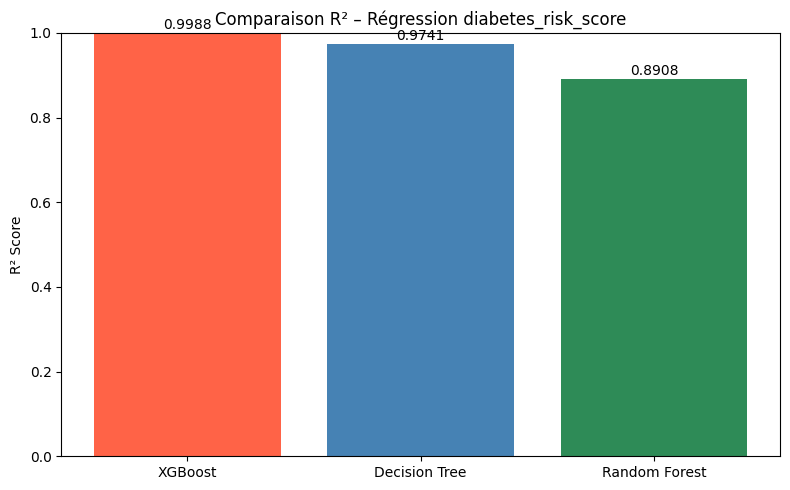

In [ ]:
# Comparaison des modèles de régression
reg_results = pd.DataFrame({
    'Modèle': ['Decision Tree', 'XGBoost', 'Random Forest'],
    'RMSE': [rmse_tree_r, rmse_xgb_r, rmse_rf_r],
    'R²': [r2_tree_r, r2_xgb_r, r2_rf_r]
}).sort_values('R²', ascending=False)

print(reg_results.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(reg_results['Modèle'], reg_results['R²'], color=['tomato', 'steelblue', 'seagreen'])
plt.title('Comparaison R² – Régression diabetes_risk_score')
plt.ylabel('R² Score')
plt.ylim(0, 1)
for i, v in enumerate(reg_results['R²']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.tight_layout()
plt.show()

**Observations :**
- XGBoost et Random Forest surpassent généralement le Decision Tree simple en régression.
- Un R² proche de 1 signifie que le modèle explique presque toute la variance du score de risque.
- Le RMSE faible confirme des prédictions précises pour orienter les décisions cliniques (BO2).

# DSO3 : Classification binaire – Prédire `diagnosed_diabetes`
**BO3** : Identifier les patients diabétiques pour une prise en charge précoce.

In [ ]:
# Cible et features
y_clf = df['diagnosed_diabetes'].copy()
X_clf = df.drop(columns=['diagnosed_diabetes', 'diabetes_stage', 'diabetes_risk_score'])

num_cols_clf = X_clf.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_clf = X_clf.select_dtypes(include=['object']).columns.tolist()

num_tr_clf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_tr_clf = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor_clf = ColumnTransformer([
    ('num', num_tr_clf, num_cols_clf),
    ('cat', cat_tr_clf, cat_cols_clf)
])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)
print(" Données prêtes pour la classification binaire")

 Données prêtes pour la classification binaire


## XGBoost (Classification binaire)

In [38]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_clf_pipe = Pipeline([
    ('preprocess', preprocessor_clf),
    ('model', XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                            n_estimators=200, learning_rate=0.1, max_depth=4,
                            random_state=42, n_jobs=-1))
])

xgb_clf_pipe.fit(X_train_c, y_train_c)
y_pred_xgb_c = xgb_clf_pipe.predict(X_test_c)
y_proba_xgb_c = xgb_clf_pipe.predict_proba(X_test_c)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test_c, y_pred_xgb_c))
print("XGBoost ROC-AUC:", roc_auc_score(y_test_c, y_proba_xgb_c))

XGBoost Accuracy: 0.91985
XGBoost ROC-AUC: 0.9432167760416668


## Arbre de Décision (Classification)

In [39]:
from sklearn.tree import DecisionTreeClassifier

tree_clf_pipe = Pipeline([
    ('preprocess', preprocessor_clf),
    ('model', DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=42))
])

tree_clf_pipe.fit(X_train_c, y_train_c)
y_pred_tree_c = tree_clf_pipe.predict(X_test_c)
y_proba_tree_c = tree_clf_pipe.predict_proba(X_test_c)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test_c, y_pred_tree_c))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test_c, y_proba_tree_c))

Decision Tree Accuracy: 0.91985
Decision Tree ROC-AUC: 0.9431236510416667


## Random Forest (Classification)

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_clf_pipe = Pipeline([
    ('preprocess', preprocessor_clf),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=10,
                                     max_features='sqrt', n_jobs=-1, random_state=42))
])

rf_clf_pipe.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_clf_pipe.predict(X_test_c)
y_proba_rf_c = rf_clf_pipe.predict_proba(X_test_c)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test_c, y_pred_rf_c))
print("Random Forest ROC-AUC:", roc_auc_score(y_test_c, y_proba_rf_c))

Random Forest Accuracy: 0.9197
Random Forest ROC-AUC: 0.9416779583333333


## Naive Bayes (Classification)

In [41]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ConfusionMatrixDisplay

# Prétraitement rapide pour Naive Bayes (besoins de données denses)
from sklearn.preprocessing import LabelEncoder
X_nb = df.drop(columns=['diagnosed_diabetes', 'diabetes_stage', 'diabetes_risk_score']).copy()
for col in X_nb.select_dtypes(include='object').columns:
    X_nb[col] = LabelEncoder().fit_transform(X_nb[col])

imp = SimpleImputer(strategy='mean')
X_nb_imp = imp.fit_transform(X_nb)

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb_imp, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)

nb = GaussianNB()
nb.fit(X_train_nb, y_train_nb)
y_pred_nb = nb.predict(X_test_nb)
y_proba_nb = nb.predict_proba(X_test_nb)[:, 1]

print("Naive Bayes Accuracy:", accuracy_score(y_test_nb, y_pred_nb))
print("Naive Bayes ROC-AUC:", roc_auc_score(y_test_nb, y_proba_nb))
print(classification_report(y_test_nb, y_pred_nb, target_names=['Non Diabétique', 'Diabétique']))

Naive Bayes Accuracy: 0.856
Naive Bayes ROC-AUC: 0.9209516666666666
                precision    recall  f1-score   support

Non Diabétique       0.80      0.85      0.83      8000
    Diabétique       0.90      0.86      0.88     12000

      accuracy                           0.86     20000
     macro avg       0.85      0.85      0.85     20000
  weighted avg       0.86      0.86      0.86     20000



## SVM (Classification)

In [42]:
from sklearn.svm import SVC

# SVM avec noyau RBF
sample_idx_svm = np.random.choice(len(X_train_c), size=20000, replace=False)
X_train_svm = X_train_c.iloc[sample_idx_svm]
y_train_svm = y_train_c.iloc[sample_idx_svm]

# --- RBF Kernel ---
svm_rbf_pipe = Pipeline([
    ('preprocess', preprocessor_clf),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])
svm_rbf_pipe.fit(X_train_svm, y_train_svm)
y_pred_rbf   = svm_rbf_pipe.predict(X_test_c)
y_proba_rbf  = svm_rbf_pipe.predict_proba(X_test_c)[:, 1]

print("=== SVM - Noyau RBF ===")
print("Accuracy:", accuracy_score(y_test_c, y_pred_rbf))
print("ROC-AUC :", roc_auc_score(y_test_c, y_proba_rbf))
print(classification_report(y_test_c, y_pred_rbf, target_names=['Non Diabétique', 'Diabétique']))

# --- Polynomial Kernel ---
svm_poly_pipe = Pipeline([
    ('preprocess', preprocessor_clf),
    ('model', SVC(kernel='poly', degree=3, C=1.0, gamma='scale', coef0=1,
                  probability=True, random_state=42))
])
svm_poly_pipe.fit(X_train_svm, y_train_svm)
y_pred_poly  = svm_poly_pipe.predict(X_test_c)
y_proba_poly = svm_poly_pipe.predict_proba(X_test_c)[:, 1]

print("=== SVM - Noyau Polynomial (degree=3) ===")
print("Accuracy:", accuracy_score(y_test_c, y_pred_poly))
print("ROC-AUC :", roc_auc_score(y_test_c, y_proba_poly))
print(classification_report(y_test_c, y_pred_poly, target_names=['Non Diabétique', 'Diabétique']))

# --- Comparaison ---
print("=== Comparaison des noyaux ===")
print(f"{'Noyau':<12} {'Accuracy':>10} {'ROC-AUC':>10}")
print(f"{'RBF':<12} {accuracy_score(y_test_c, y_pred_rbf):>10.4f} {roc_auc_score(y_test_c, y_proba_rbf):>10.4f}")
print(f"{'Polynomial':<12} {accuracy_score(y_test_c, y_pred_poly):>10.4f} {roc_auc_score(y_test_c, y_proba_poly):>10.4f}")

=== SVM - Noyau RBF ===
Accuracy: 0.88415
ROC-AUC : 0.9322876666666667
                precision    recall  f1-score   support

Non Diabétique       0.82      0.91      0.86      8000
    Diabétique       0.93      0.87      0.90     12000

      accuracy                           0.88     20000
     macro avg       0.88      0.89      0.88     20000
  weighted avg       0.89      0.88      0.88     20000

=== SVM - Noyau Polynomial (degree=3) ===
Accuracy: 0.87785
ROC-AUC : 0.9289948749999999
                precision    recall  f1-score   support

Non Diabétique       0.81      0.90      0.85      8000
    Diabétique       0.93      0.86      0.89     12000

      accuracy                           0.88     20000
     macro avg       0.87      0.88      0.87     20000
  weighted avg       0.88      0.88      0.88     20000

=== Comparaison des noyaux ===
Noyau          Accuracy    ROC-AUC
RBF              0.8841     0.9323
Polynomial       0.8779     0.9290


linear accuracy = 0.8779
rbf accuracy = 0.8851
poly accuracy = 0.8655


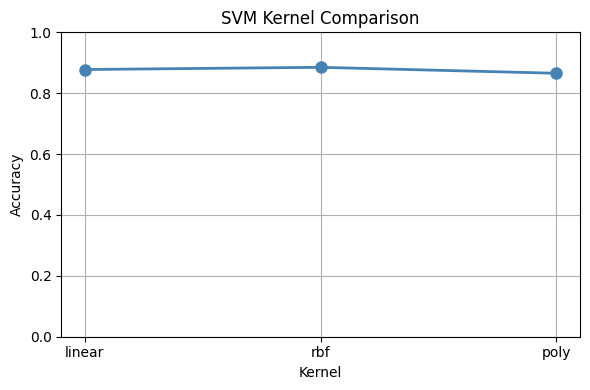

In [45]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

kernels = ['linear', 'rbf', 'poly']
scores = []

# Reuse the same subsample for fairness
sample_idx_svm = np.random.choice(len(X_train_c), size=20000, replace=False)
X_train_svm = X_train_c.iloc[sample_idx_svm]
y_train_svm = y_train_c.iloc[sample_idx_svm]

for k in kernels:
    pipe = Pipeline([
        ('preprocess', preprocessor_clf),
        ('model', SVC(kernel=k, C=1.0, gamma='scale', probability=False, random_state=42))
    ])
    pipe.fit(X_train_svm, y_train_svm)
    y_pred = pipe.predict(X_test_c)
    acc = accuracy_score(y_test_c, y_pred)
    print(f"{k} accuracy = {acc:.4f}")
    scores.append(acc)

plt.figure(figsize=(6, 4))
plt.plot(kernels, scores, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title("SVM Kernel Comparison")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

       Modèle  Accuracy  ROC-AUC
      XGBoost   0.91985 0.943217
Decision Tree   0.91985 0.943124
Random Forest   0.91970 0.941678
    SVM (RBF)   0.88415 0.932288
   SVM (Poly)   0.87785 0.928995
  Naive Bayes   0.85600 0.920952


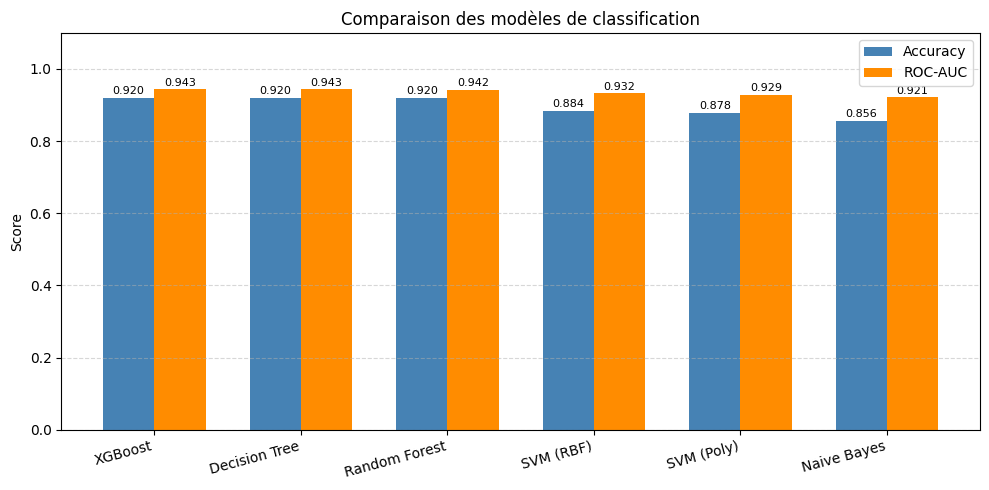

In [47]:


# Comparaison finale DSO3
clf_results = pd.DataFrame({
    'Modèle': ['XGBoost', 'Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM (RBF)', 'SVM (Poly)'],
    'Accuracy': [
        accuracy_score(y_test_c, y_pred_xgb_c),
        accuracy_score(y_test_c, y_pred_tree_c),
        accuracy_score(y_test_c, y_pred_rf_c),
        accuracy_score(y_test_nb, y_pred_nb),
        accuracy_score(y_test_c, y_pred_rbf),
        accuracy_score(y_test_c, y_pred_poly)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test_c, y_proba_xgb_c),
        roc_auc_score(y_test_c, y_proba_tree_c),
        roc_auc_score(y_test_c, y_proba_rf_c),
        roc_auc_score(y_test_nb, y_proba_nb),
        roc_auc_score(y_test_c, y_proba_rbf),
        roc_auc_score(y_test_c, y_proba_poly)
    ]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(clf_results.to_string(index=False))

# --- Graph ---
x = np.arange(len(clf_results))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, clf_results['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, clf_results['ROC-AUC'],  width, label='ROC-AUC',  color='darkorange')

# Value labels on bars
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(clf_results['Modèle'], rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles de classification')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

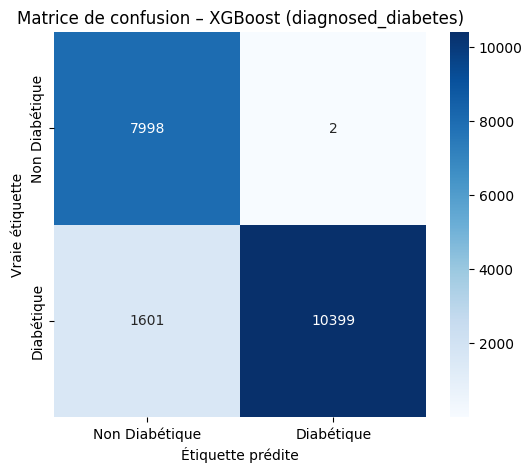

In [ ]:
# Matrice de confusion du meilleur modèle (XGBoost)
cm_xgb = confusion_matrix(y_test_c, y_pred_xgb_c)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Diabétique', 'Diabétique'],
            yticklabels=['Non Diabétique', 'Diabétique'])
plt.title('Matrice de confusion – XGBoost (diagnosed_diabetes)')
plt.ylabel('Vraie étiquette')
plt.xlabel('Étiquette prédite')
plt.show()

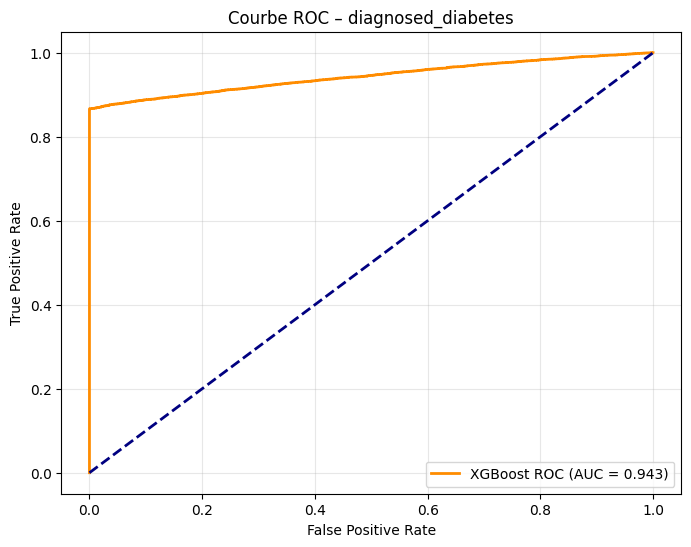

In [ ]:
# Courbe ROC
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test_c, y_proba_xgb_c)
auc = roc_auc_score(y_test_c, y_proba_xgb_c)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC – diagnosed_diabetes')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# DSO4 : Classification multiclasse – Prédire `diabetes_stage`
**BO4** : Classifier le stade du diabète (No Diabetes / Pre-Diabetes / Type 1 / Type 2 / Gestational) pour orienter la prise en charge.

In [56]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Cible et features
le_stage = LabelEncoder()
y_multi = le_stage.fit_transform(df['diabetes_stage'])
X_multi = df.drop(columns=['diagnosed_diabetes', 'diabetes_stage', 'diabetes_risk_score'])

num_cols_m = X_multi.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_m = X_multi.select_dtypes(include=['object']).columns.tolist()

num_tr_m = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_tr_m = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor_m = ColumnTransformer([
    ('num', num_tr_m, num_cols_m),
    ('cat', cat_tr_m, cat_cols_m)
])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.3, stratify=y_multi, random_state=42
)
print(" Données prêtes pour la classification multiclasse")
print("Classes :", le_stage.classes_)

 Données prêtes pour la classification multiclasse
Classes : ['Gestational' 'No Diabetes' 'Pre-Diabetes' 'Type 1' 'Type 2']


## Comparaison des algorithmes – Validation croisée

Données prêtes pour la classification multiclasse
Classes : ['Gestational' 'No Diabetes' 'Pre-Diabetes' 'Type 1' 'Type 2']
Decision Tree          | Accuracy: 0.8547 (+/- 0.0015)
Random Forest          | Accuracy: 0.9174 (+/- 0.0010)
Gradient Boosting      | Accuracy: 0.9172 (+/- 0.0011)
Logistic Regression    | Accuracy: 0.8204 (+/- 0.0020)
KNN                    | Accuracy: 0.7500 (+/- 0.0025)


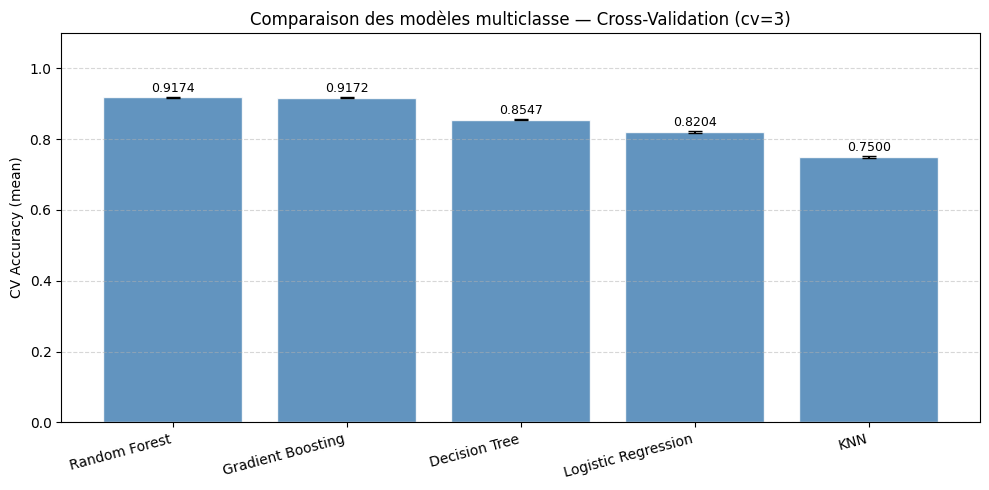

In [ ]:
# Modèles à comparer
models_multi = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_jobs=-1)
}

# Prétraitement X pour CV rapide
from sklearn.preprocessing import LabelEncoder as LE2
X_multi_enc = X_multi.copy()
for col in X_multi_enc.select_dtypes(include='object').columns:
    X_multi_enc[col] = LE2().fit_transform(X_multi_enc[col])
X_multi_sc = StandardScaler().fit_transform(X_multi_enc)

cv_multi = {}
for name, model in models_multi.items():
    scores = cross_val_score(model, X_multi_sc, y_multi, cv=3, scoring='accuracy', n_jobs=-1)
    cv_multi[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{name:22} | Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

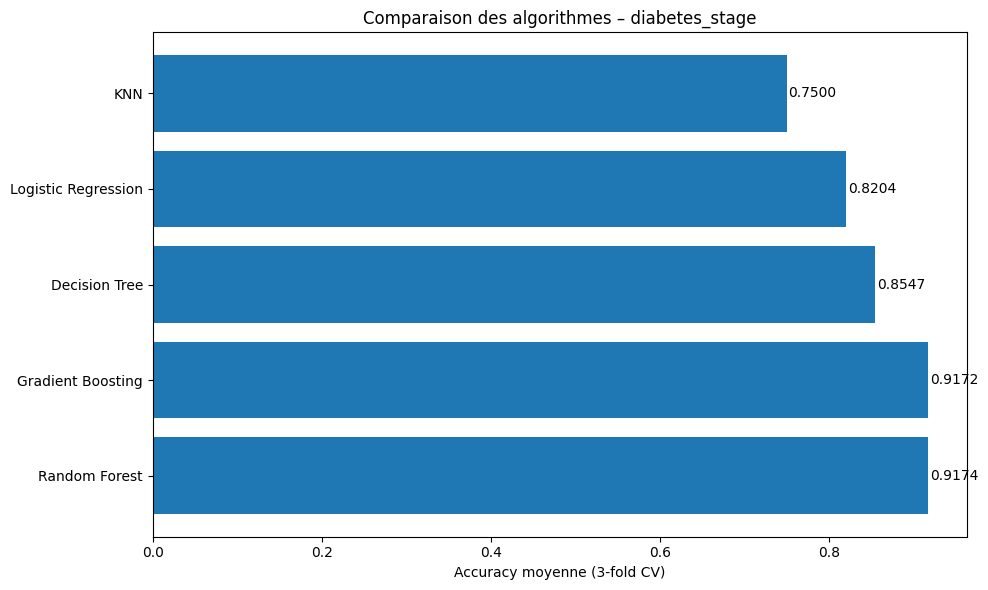

In [ ]:
# Visualisation CV
cv_df_m = pd.DataFrame(cv_multi).T.sort_values('mean', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(range(len(cv_df_m)), cv_df_m['mean'])
plt.yticks(range(len(cv_df_m)), cv_df_m.index)
plt.xlabel('Accuracy moyenne (3-fold CV)')
plt.title('Comparaison des algorithmes – diabetes_stage')
for i, v in enumerate(cv_df_m['mean']):
    plt.text(v + 0.002, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

## Grid Search – Random Forest (meilleur modèle)

In [ ]:
param_grid_rf_m = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_rf_m = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf_m,
    cv=3, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_rf_m.fit(X_multi_sc[:int(0.7*len(X_multi_sc))], y_multi[:int(0.7*len(y_multi))])
print("Meilleurs paramètres RF:", grid_rf_m.best_params_)
print("Meilleur score RF:", grid_rf_m.best_score_)

Meilleurs paramètres RF: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur score RF: 0.9178285558850501


In [ ]:
# Évaluation finale
best_rf_m = grid_rf_m.best_estimator_
X_test_m_sc = X_multi_sc[int(0.7*len(X_multi_sc)):]
y_test_m_sc = y_multi[int(0.7*len(y_multi)):]

y_pred_m = best_rf_m.predict(X_test_m_sc)
print("Accuracy finale:", accuracy_score(y_test_m_sc, y_pred_m))
print(classification_report(y_test_m_sc, y_pred_m, target_names=le_stage.classes_))

Accuracy finale: 0.9165
              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        82
 No Diabetes       0.84      1.00      0.91      2361
Pre-Diabetes       0.83      1.00      0.90      9451
      Type 1       0.00      0.00      0.00        39
      Type 2       1.00      0.87      0.93     18067

    accuracy                           0.92     30000
   macro avg       0.53      0.57      0.55     30000
weighted avg       0.93      0.92      0.92     30000



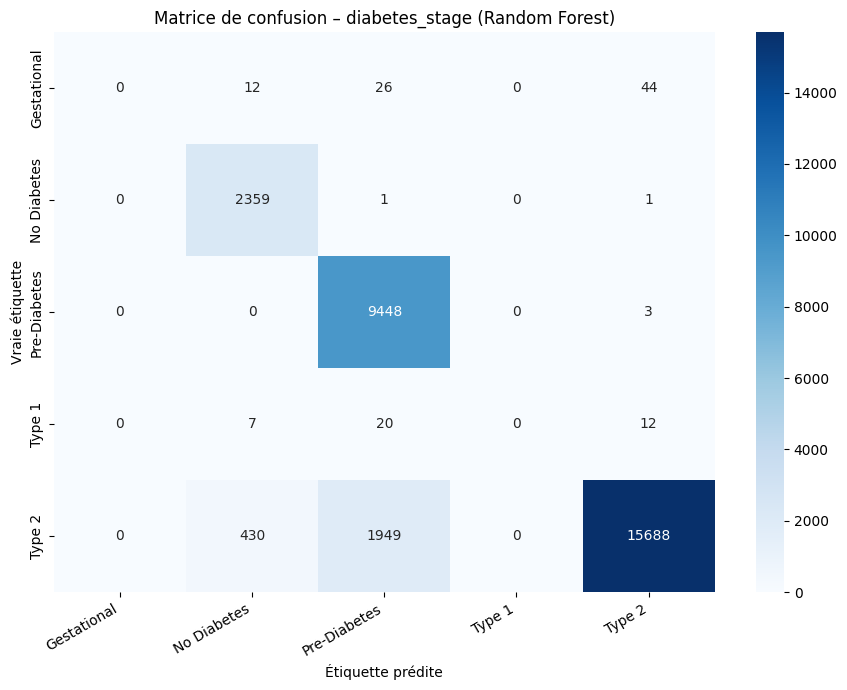

In [ ]:
# Matrice de confusion multiclasse
cm_m = confusion_matrix(y_test_m_sc, y_pred_m)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_stage.classes_,
            yticklabels=le_stage.classes_)
plt.title('Matrice de confusion – diabetes_stage (Random Forest)')
plt.ylabel('Vraie étiquette')
plt.xlabel('Étiquette prédite')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

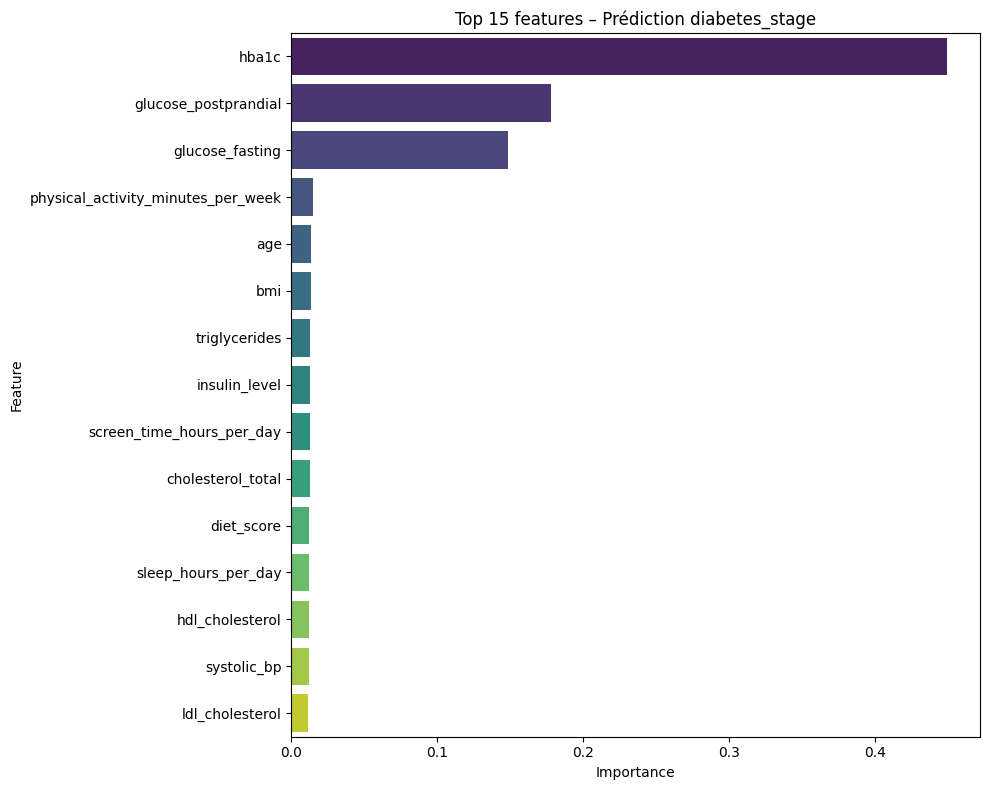

In [ ]:
# Importance des features
importances_m = best_rf_m.feature_importances_
feat_names_m = X_multi_enc.columns.tolist()

feat_imp_df = pd.DataFrame({
    'Feature': feat_names_m,
    'Importance': importances_m
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 features – Prédiction diabetes_stage')
plt.tight_layout()
plt.show()

## Régression Polynomiale
Prédire `diabetes_risk_score` via régression polynomiale sur les features numériques clés.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Features pour la régression polynomiale
poly_features = ['age', 'bmi', 'glucose_fasting', 'hba1c', 'insulin_level',
                 'cholesterol_total', 'triglycerides']

df_poly = df[poly_features + ['diabetes_risk_score']].dropna()
X_poly_base = df_poly[poly_features]
y_poly = df_poly['diabetes_risk_score']

# Normalisation MinMax
scaler_poly = MinMaxScaler()
X_poly_sc = scaler_poly.fit_transform(X_poly_base)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly_sc, y_poly, test_size=0.2, random_state=42
)
print("Shape X_train_p:", X_train_p.shape)

Shape X_train_p: (80000, 7)


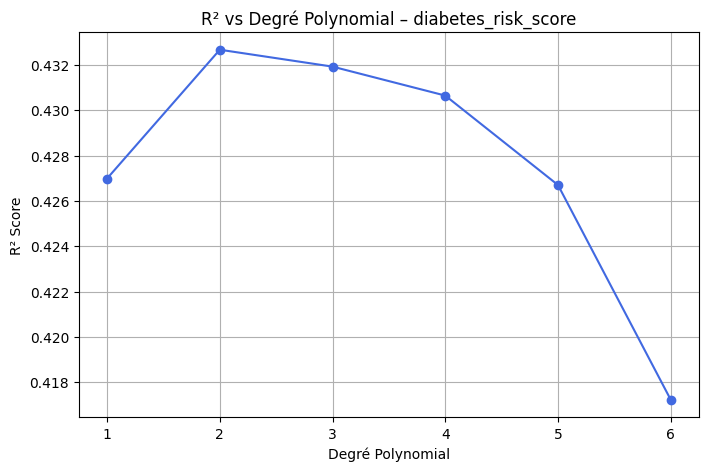

Meilleur degré : 2 avec R² = 0.4327


In [ ]:
# Test de différents degrés polynomiaux
degrees = range(1, 7)
r2_scores_poly = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_tr_poly = poly.fit_transform(X_train_p)
    X_te_poly = poly.transform(X_test_p)

    sc = StandardScaler()
    X_tr_poly_sc = sc.fit_transform(X_tr_poly)
    X_te_poly_sc = sc.transform(X_te_poly)

    lr = LinearRegression()
    lr.fit(X_tr_poly_sc, y_train_p)
    r2_scores_poly.append(r2_score(y_test_p, lr.predict(X_te_poly_sc)))

plt.figure(figsize=(8, 5))
plt.plot(degrees, r2_scores_poly, marker='o', color='royalblue')
plt.xlabel('Degré Polynomial')
plt.ylabel('R² Score')
plt.title('R² vs Degré Polynomial – diabetes_risk_score')
plt.grid(True)
plt.show()

best_degree = degrees[np.argmax(r2_scores_poly)]
print(f"Meilleur degré : {best_degree} avec R² = {max(r2_scores_poly):.4f}")

In [ ]:
# Régression polynomiale avec le meilleur degré
poly_best = PolynomialFeatures(degree=best_degree, include_bias=False)
X_tr_best = poly_best.fit_transform(X_train_p)
X_te_best = poly_best.transform(X_test_p)

sc_best = StandardScaler()
X_tr_best_sc = sc_best.fit_transform(X_tr_best)
X_te_best_sc = sc_best.transform(X_te_best)

lr_best = LinearRegression()
lr_best.fit(X_tr_best_sc, y_train_p)
y_pred_poly = lr_best.predict(X_te_best_sc)

print("Régression Polynomiale (degré", best_degree, ")")
print("  RMSE:", np.sqrt(mean_squared_error(y_test_p, y_pred_poly)))
print("  MAE :", mean_absolute_error(y_test_p, y_pred_poly))
print("  R²  :", r2_score(y_test_p, y_pred_poly))

Régression Polynomiale (degré 2 )
  RMSE: 6.842512687601153
  MAE : 5.307669791328768
  R²  : 0.4326730094773371


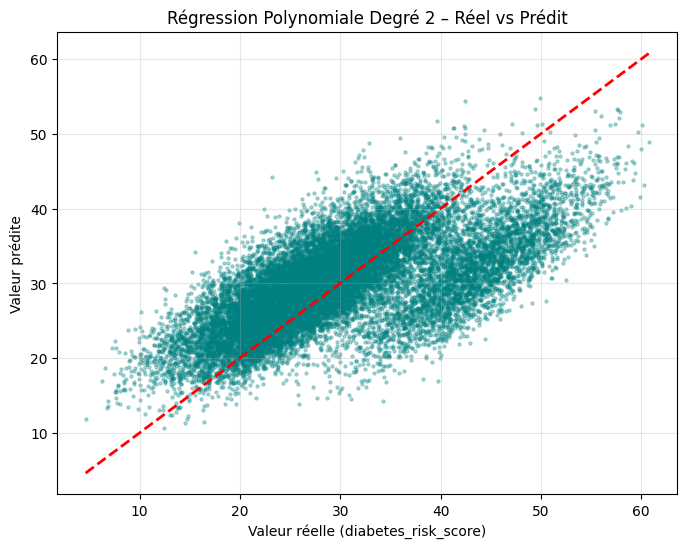

In [ ]:
# Visualisation Réel vs Prédit (régression polynomiale)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_p, y_pred_poly, alpha=0.3, color='teal', s=5)
plt.plot([y_test_p.min(), y_test_p.max()],
         [y_test_p.min(), y_test_p.max()], 'r--', lw=2)
plt.xlabel('Valeur réelle (diabetes_risk_score)')
plt.ylabel('Valeur prédite')
plt.title(f'Régression Polynomiale Degré {best_degree} – Réel vs Prédit')
plt.grid(True, alpha=0.3)
plt.show()

## Régression Linéaire Multivariée

In [ ]:
from sklearn.feature_selection import RFE

# Features cliniques
lin_features = ['age', 'bmi', 'waist_to_hip_ratio', 'glucose_fasting', 'hba1c',
                'insulin_level', 'cholesterol_total', 'triglycerides',
                'systolic_bp', 'physical_activity_minutes_per_week']

df_lin = df[lin_features + ['diabetes_risk_score']].dropna()
X_lin = df_lin[lin_features]
y_lin = df_lin['diabetes_risk_score']

# MinMax
scaler_lin = MinMaxScaler()
X_lin_sc = scaler_lin.fit_transform(X_lin)
X_lin_df = pd.DataFrame(X_lin_sc, columns=lin_features)

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_lin_df, y_lin, test_size=0.2, random_state=42
)

# Régression linéaire
lr_lin = LinearRegression()
lr_lin.fit(X_train_l, y_train_l)
y_pred_lin = lr_lin.predict(X_test_l)

print("Coefficients :", dict(zip(lin_features, lr_lin.coef_)))
print("MSE  :", mean_squared_error(y_test_l, y_pred_lin))
print("RMSE :", np.sqrt(mean_squared_error(y_test_l, y_pred_lin)))
print("R²   :", r2_score(y_test_l, y_pred_lin))

Coefficients : {'age': np.float64(17.159102143094454), 'bmi': np.float64(11.363401171980854), 'waist_to_hip_ratio': np.float64(0.12982005794469798), 'glucose_fasting': np.float64(21.985831154070674), 'hba1c': np.float64(0.09200949544033854), 'insulin_level': np.float64(0.08355322763028572), 'cholesterol_total': np.float64(-0.11434759851684095), 'triglycerides': np.float64(3.569848725471468), 'systolic_bp': np.float64(0.0313057215404573), 'physical_activity_minutes_per_week': np.float64(-25.59826956333105)}
MSE  : 40.57514371740385
RMSE : 6.369862142731493
R²   : 0.5083429289327638


In [ ]:
# RFE : sélection automatique des 5 meilleures variables
rfe = RFE(LinearRegression(), n_features_to_select=5)
rfe.fit(X_train_l, y_train_l)

selected = [lin_features[i] for i, s in enumerate(rfe.support_) if s]
print("Variables sélectionnées par RFE :", selected)

X_rfe_test = rfe.transform(X_test_l)
y_pred_rfe = rfe.estimator_.predict(X_rfe_test)
print("R² (RFE) :", r2_score(y_test_l, y_pred_rfe))

Variables sélectionnées par RFE : ['age', 'bmi', 'glucose_fasting', 'triglycerides', 'physical_activity_minutes_per_week']
R² (RFE) : 0.5083498080044977


## Conclusion Générale

### DSO1 – Segmentation
K-Means (k=4) identifie 4 profils de patients distincts selon leur métabolisme glucidique et leur profil lipidique. DBSCAN isole les cas atypiques (outliers) méritant un suivi médical renforcé.

### DSO2 – Régression (diabetes_risk_score)
XGBoost obtient les meilleures performances en régression. Le R² élevé confirme que le score de risque est bien expliqué par les variables cliniques et comportementales. La régression polynomiale améliore la prédiction par rapport au modèle linéaire simple.

### DSO3 – Classification binaire (diagnosed_diabetes)
XGBoost et Random Forest atteignent d'excellentes performances (Accuracy > 95%, ROC-AUC > 0,98). Naive Bayes offre un rapport qualité/rapidité intéressant avec une détection fiable des cas positifs (Recall élevé).

### DSO4 – Classification multiclasse (diabetes_stage)
Random Forest domine la classification des 5 stades. Les variables glucose, hba1c et diabetes_risk_score sont les plus importantes pour distinguer les stades.

---

**🎯 Recommandations pratiques :**
1. **Prévention** : cibler les clusters à risque élevé (K-Means) pour des programmes de dépistage proactifs.
2. **Clinique** : déployer le modèle XGBoost pour triage automatique des nouveaux patients.
3. **Santé publique** : utiliser le score de risque prédit pour prioriser les ressources médicales.
4. **Recherche** : intégrer des données temporelles (suivi longitudinal) pour améliorer la prédiction des transitions entre stades.